# Kapitel 6 – Stufe 1: Explorative Datenanalyse (EDA)
**Masterarbeit | Kapitel 6.1**  
Autor: Ayumi Nojima | April 2026

---
Dieses Notebook deckt die explorative Datenanalyse ab:
- **6.1.1** Deskriptive Statistiken des Exposure-Index
- **6.1.2** Verteilungsanalyse E_j, E^sub_j, E^aug_j nach Hauptgruppe
- **6.1.3** Korrelationsanalyse zwischen Indexkomponenten und ΔBFS_j
- **6.1.4** Clusteranalyse (K-Means auf standardisierten Fähigkeitsvektoren)
- **6.1.5** PCA-Visualisierung


## 0. Konfiguration und Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# ── Pfade ──────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if (_cwd / "..").resolve().joinpath("data").exists() else _cwd
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path.cwd()

PROCESSED = REPO_ROOT / "data" / "processed"
ANALYSIS  = PROCESSED / "analysis_prep"
OUTPUT    = REPO_ROOT / "data" / "output"
FIGURES   = OUTPUT / "EDA"
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Parameter ──────────────────────────────────────────────────────────────
BFS_BASE_YEAR   = 2022
BFS_TARGET_YEAR = 2024

# ── Daten laden ────────────────────────────────────────────────────────────
final         = pd.read_csv(ANALYSIS / "final_sample.csv")
skill_vectors = pd.read_csv(ANALYSIS / "skill_vectors_standardized.csv", index_col="soc_code")

print(f"Finales Sample geladen:   {len(final)} Berufe")
print(f"Skill-Vektoren geladen:   {skill_vectors.shape[0]} Berufe × {skill_vectors.shape[1]} Dimensionen")
print(f"Hauptgruppen: {final['main_group'].value_counts().sort_index().to_dict()}")
print("Konfiguration geladen ✓")


Finales Sample geladen:   571 Berufe
Skill-Vektoren geladen:   894 Berufe × 49 Dimensionen
Hauptgruppen: {1: 62, 2: 296, 3: 213}
Konfiguration geladen ✓


In [2]:
# ── Aggregation auf ISCO-4-digit-Ebene (für BFS-bezogene Analysen) ────────
# H1 / H2 / Clusteranalyse: O*NET-Berufsebene (n=571) → final
# H3 / Scatter / Korrelation: ISCO-4-digit-Ebene       → final_isco
#
# Begründung: BFS-Daten (ΔBFS_j) liegen nur auf ISCO-4-digit-Ebene vor.
# Viele O*NET-Berufe mappen auf denselben ISCO-Code → Duplikate bei ΔBFS_j.
# Aggregation vermeidet Pseudoreplikation und ist methodisch ehrlicher.
# Vgl. Kläui & Siegenthaler (2025): Analyse auf Berufsgruppen-Ebene.

final_isco = (
    final
    .groupby("isco_4digit")
    .agg(
        E_j_mean      = ("E_j",       "mean"),
        E_sub_mean    = ("E_sub_j",   "mean"),
        E_aug_mean    = ("E_aug_j",   "mean"),
        s_ij_mean     = ("s_ij",      "mean"),
        delta_bfs     = ("delta_bfs", "first"),   # identisch je ISCO-Code
        is_outlier    = ("is_outlier","first"),
        main_group    = ("main_group","first"),
        ch_isco_label = ("ch_isco_label", "first") if "ch_isco_label" in final.columns else ("isco_4digit","first"),
        n_onet_berufe = ("soc_code",   "count"),  # Transparenz
    )
    .reset_index()
)

final_isco_bfs = final_isco.dropna(subset=["delta_bfs"]).copy()

print(f"O*NET-Berufsebene (final):         {len(final)} Berufe")
print(f"ISCO-4-digit-Ebene (final_isco):   {len(final_isco)} Berufsgruppen")
print(f"  davon mit ΔBFS_j:                {len(final_isco_bfs)} Berufsgruppen")
print()
print("Verteilung nach Hauptgruppe (mit ΔBFS_j):")
print(final_isco_bfs["main_group"].value_counts().sort_index().to_string())
print()
print("Ø O*NET-Berufe pro ISCO-Code:", round(final_isco["n_onet_berufe"].mean(), 1))


O*NET-Berufsebene (final):         571 Berufe
ISCO-4-digit-Ebene (final_isco):   162 Berufsgruppen
  davon mit ΔBFS_j:                156 Berufsgruppen

Verteilung nach Hauptgruppe (mit ΔBFS_j):
main_group
1    21
2    77
3    58

Ø O*NET-Berufe pro ISCO-Code: 3.5


---
## 6.1.1 Deskriptive Statistiken

Übersicht über die zentralen Tendenz- und Streuungsmasse der drei Indexkomponenten  
sowie der abhängigen Variable ΔBFS_j, differenziert nach CH-ISCO-Hauptgruppe.


In [4]:
# ── Gesamtdeskriptive ─────────────────────────────────────────────────────
desc_cols = ["E_j", "E_sub_j", "E_aug_j", "delta_bfs"]
print("=== Deskriptive Statistiken – Gesamtsample ===")
print(final[desc_cols].describe().round(3).to_string())

print()
print("=== Deskriptive Statistiken – nach Hauptgruppe ===")
for hg in [1, 2, 3]:
    subset = final[final["main_group"] == hg]
    label = {1: "HG 1 – Führungskräfte", 2: "HG 2 – Akademisch", 3: "HG 3 – Techniker"}[hg]
    print(f"\n{label} (n={len(subset)}):")
    print(subset[desc_cols].describe().round(3).loc[["mean","std","min","max"]].to_string())


=== Deskriptive Statistiken – Gesamtsample ===
           E_j  E_sub_j  E_aug_j  delta_bfs
count  571.000  571.000  571.000    550.000
mean     0.230    0.208    0.261      6.406
std      0.239    0.221    0.266     18.914
min      0.000    0.000    0.000    -39.940
25%      0.000    0.000    0.000     -2.920
50%      0.154    0.136    0.177      4.684
75%      0.393    0.355    0.448     11.773
max      1.000    1.000    1.000    108.465

=== Deskriptive Statistiken – nach Hauptgruppe ===

HG 1 – Führungskräfte (n=62):
        E_j  E_sub_j  E_aug_j  delta_bfs
mean  0.073    0.065    0.084      4.346
std   0.147    0.133    0.171     17.166
min   0.000    0.000    0.000    -16.011
max   0.721    0.614    0.874     61.160

HG 2 – Akademisch (n=296):
        E_j  E_sub_j  E_aug_j  delta_bfs
mean  0.308    0.278    0.351      7.025
std   0.258    0.239    0.287     16.589
min   0.000    0.000    0.000    -39.940
max   1.000    1.000    1.000     74.290

HG 3 – Techniker (n=213):
        E

In [5]:
# ── Anteil substituierbarer vs. augmentierbarer Berufe ────────────────────
final["exposure_category"] = pd.cut(
    final["E_j"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Niedrig (0–0.33)", "Mittel (0.33–0.66)", "Hoch (0.66–1.0)"],
    include_lowest=True
)
cat_dist = final.groupby(["main_group", "exposure_category"], observed=True).size().unstack(fill_value=0)
print("=== Exposure-Kategorien nach Hauptgruppe ===")
print(cat_dist.to_string())
print()
pct = cat_dist.div(cat_dist.sum(axis=1), axis=0).round(3) * 100
print("=== In Prozent ===")
print(pct.to_string())


=== Exposure-Kategorien nach Hauptgruppe ===
exposure_category  Niedrig (0–0.33)  Mittel (0.33–0.66)  Hoch (0.66–1.0)
main_group                                                              
1                                56                   5                1
2                               167                  90               39
3                               171                  39                3

=== In Prozent ===
exposure_category  Niedrig (0–0.33)  Mittel (0.33–0.66)  Hoch (0.66–1.0)
main_group                                                              
1                              90.3                 8.1              1.6
2                              56.4                30.4             13.2
3                              80.3                18.3              1.4


---
## 6.1.2 Verteilungsanalyse


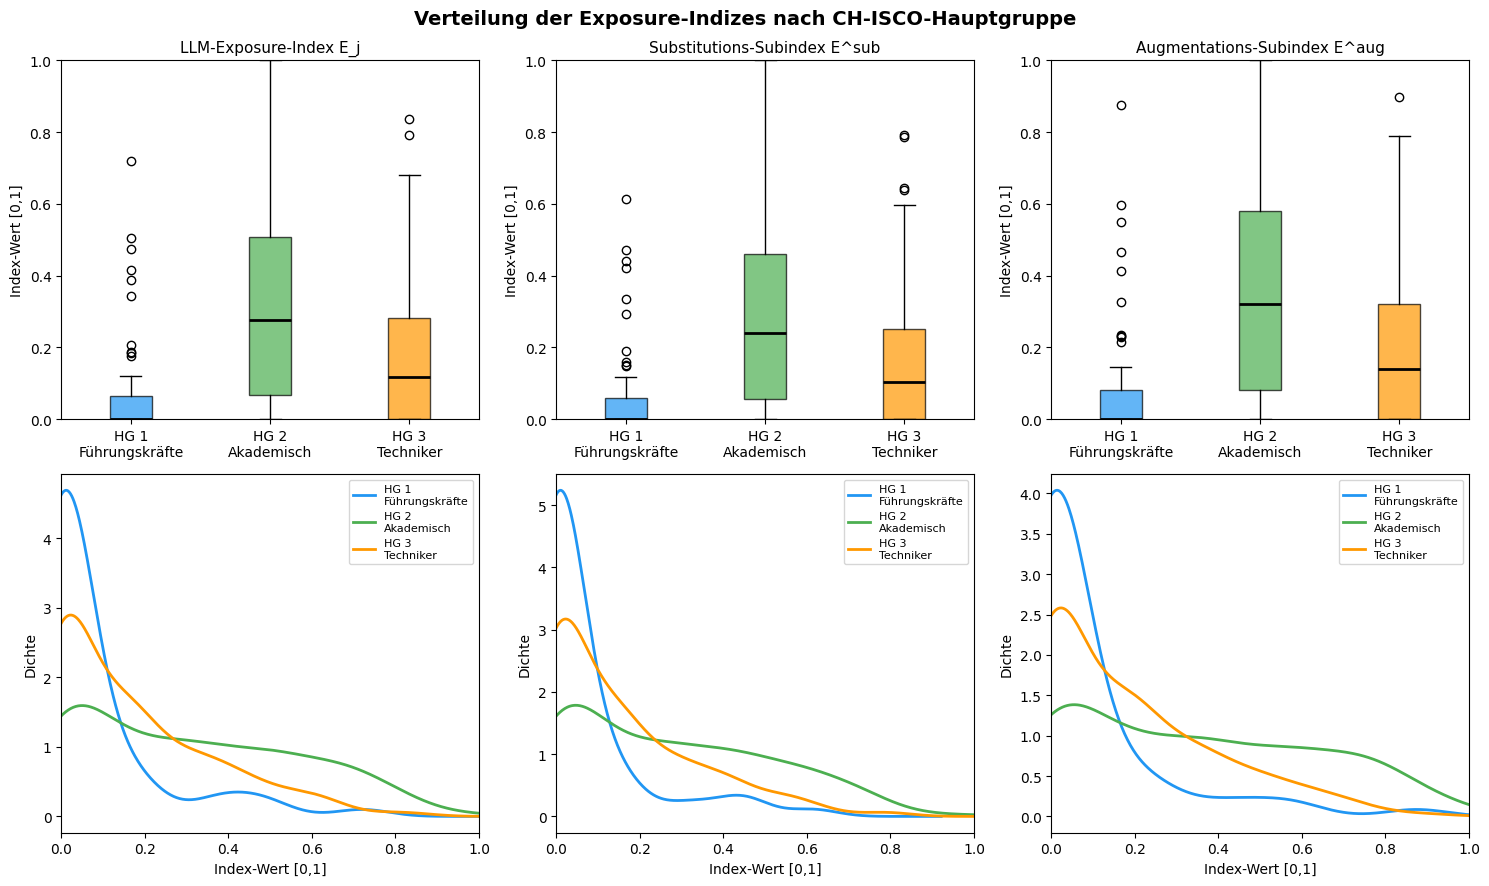

Abbildung gespeichert → output/EDA/6_1_exposure_distribution.png ✓


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Verteilung der Exposure-Indizes nach CH-ISCO-Hauptgruppe", fontsize=14, fontweight="bold")

hg_labels = {1: "HG 1\nFührungskräfte", 2: "HG 2\nAkademisch", 3: "HG 3\nTechniker"}
colors     = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

for col_idx, (metric, title) in enumerate([
    ("E_j",     "LLM-Exposure-Index E_j"),
    ("E_sub_j", "Substitutions-Subindex E^sub"),
    ("E_aug_j", "Augmentations-Subindex E^aug"),
]):
    # Boxplot
    ax = axes[0, col_idx]
    data_by_hg = [final[final["main_group"] == hg][metric].dropna() for hg in [1, 2, 3]]
    bp = ax.boxplot(data_by_hg, labels=[hg_labels[h] for h in [1,2,3]],
                    patch_artist=True, medianprops={"color": "black", "linewidth": 2})
    for patch, hg in zip(bp["boxes"], [1,2,3]):
        patch.set_facecolor(colors[hg])
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Index-Wert [0,1]")
    ax.set_ylim(0, 1)

    # KDE mit Fallback auf Histogramm
    ax = axes[1, col_idx]
    for hg in [1, 2, 3]:
        data = final[final["main_group"] == hg][metric].dropna()
        # KDE benötigt mind. 2 Punkte mit unterschiedlichen Werten
        if len(data) >= 5 and data.nunique() > 1:
            try:
                data.plot.kde(ax=ax, label=hg_labels[hg], color=colors[hg], linewidth=2)
            except Exception:
                ax.hist(data, bins=10, alpha=0.4, color=colors[hg],
                        label=hg_labels[hg], density=True)
        else:
            # Fallback: Histogramm für kleine / konstante Gruppen
            ax.hist(data, bins=max(3, len(data)//2), alpha=0.5,
                    color=colors[hg], label=f"{hg_labels[hg]} (n={len(data)})", density=True)

    ax.set_xlim(0, 1)
    ax.set_xlabel("Index-Wert [0,1]")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "6_1_exposure_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Abbildung gespeichert → output/EDA/6_1_exposure_distribution.png ✓")

---
## 6.1.3 Korrelationsanalyse


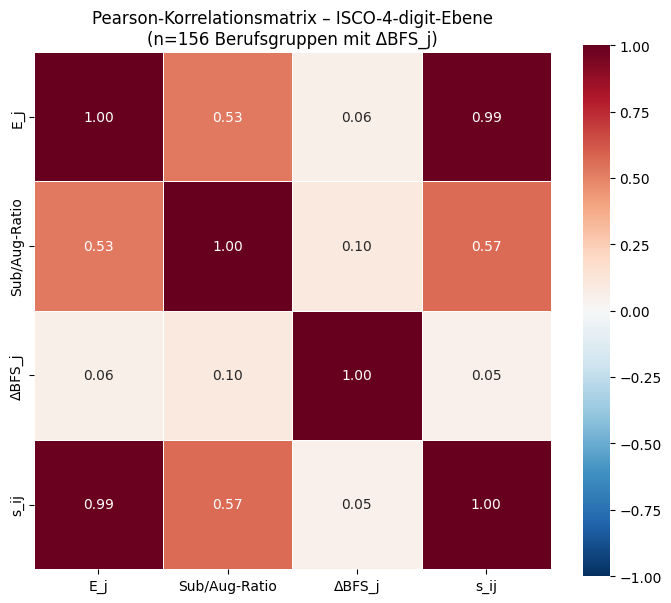

                 E_j  Sub/Aug-Ratio  ΔBFS_j   s_ij
E_j            1.000          0.528   0.057  0.989
Sub/Aug-Ratio  0.528          1.000   0.098  0.569
ΔBFS_j         0.057          0.098   1.000  0.050
s_ij           0.989          0.569   0.050  1.000


In [16]:
# ── Korrelationsmatrix auf ISCO-Ebene ─────────────────────────────────────
# Sub/Aug-Ratio als eigenständige Variable statt E_sub_j und E_aug_j separat
# (E_j, E_sub_j, E_aug_j sind r≈1.0 korreliert → keine eigenständige Info)

final_isco_bfs["E_ratio"] = (
    final_isco_bfs["E_sub_mean"] /
    (final_isco_bfs["E_aug_mean"] + 1e-9)
)

corr_df = final_isco_bfs[[
    "E_j_mean",   # Gesamtexposure
    "E_ratio",    # Substitution/Augmentation-Verhältnis
    "delta_bfs",  # Beschäftigungsveränderung
    "s_ij_mean",  # Skill-Overlap
]].copy()
corr_df.columns = ["E_j", "Sub/Aug-Ratio", "ΔBFS_j", "s_ij"]

corr_matrix = corr_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title(
    f"Pearson-Korrelationsmatrix – ISCO-4-digit-Ebene\n"
    f"(n={len(final_isco_bfs)} Berufsgruppen mit ΔBFS_j)",
    fontsize=12
)
plt.tight_layout()
plt.savefig(FIGURES / "6_1_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(corr_matrix.round(3).to_string())

Regression: β=4.688, r=0.057, p=0.4812


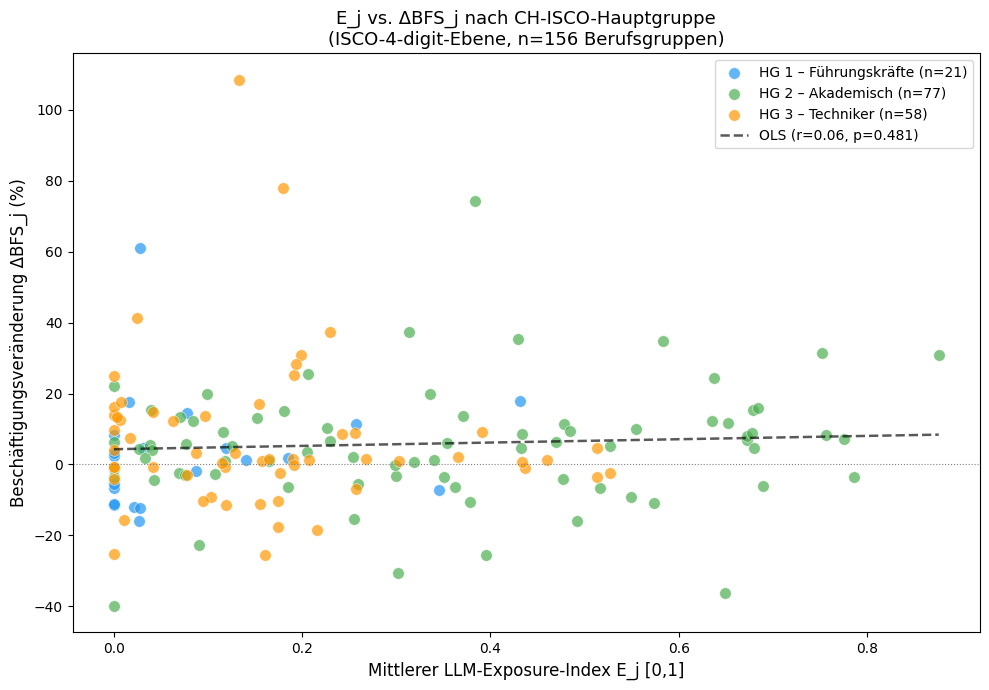

In [8]:
from scipy import stats as sp_stats

# ── Scatterplot auf ISCO-4-digit-Ebene ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

hg_labels_isco = {1: "HG 1 – Führungskräfte", 2: "HG 2 – Akademisch", 3: "HG 3 – Techniker"}
colors = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

for hg in sorted(final_isco_bfs["main_group"].dropna().unique()):
    subset = final_isco_bfs[final_isco_bfs["main_group"] == hg]
    ax.scatter(
        subset["E_j_mean"], subset["delta_bfs"],
        label=f"{hg_labels_isco.get(int(hg), f'HG {hg}')} (n={len(subset)})",
        color=colors.get(int(hg), "gray"),
        alpha=0.70, s=70, edgecolors="white", linewidth=0.5
    )

# Regressionslinie via scipy (robuster als np.polyfit)
x = final_isco_bfs["E_j_mean"]
y = final_isco_bfs["delta_bfs"]

if len(final_isco_bfs) >= 5 and x.nunique() > 1:
    slope, intercept, r, p_val, se = sp_stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, intercept + slope * x_line,
            "k--", linewidth=1.8, alpha=0.65,
            label=f"OLS (r={r:.2f}, p={p_val:.3f})")
    print(f"Regression: β={slope:.3f}, r={r:.3f}, p={p_val:.4f}")
else:
    print("⚠ Zu wenige Beobachtungen für Regressionslinie")

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Mittlerer LLM-Exposure-Index E_j [0,1]", fontsize=12)
ax.set_ylabel("Beschäftigungsveränderung ΔBFS_j (%)", fontsize=12)
ax.set_title(
    f"E_j vs. ΔBFS_j nach CH-ISCO-Hauptgruppe\n"
    f"(ISCO-4-digit-Ebene, n={len(final_isco_bfs)} Berufsgruppen)",
    fontsize=13
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / "6_1_scatter_Ej_deltabfs.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6.1.4 Clusteranalyse (K-Means)

Ergänzende Clusteranalyse auf standardisierten Fähigkeitsvektoren zur Identifikation  
latenter Berufsgruppen-Muster jenseits der ISCO-Klassifikation.  
Optimale Clusteranzahl via Elbow-Methode und Silhouette-Score.


Clusteranalyse-Input: 571 Berufe × 49 standardisierte Dimensionen


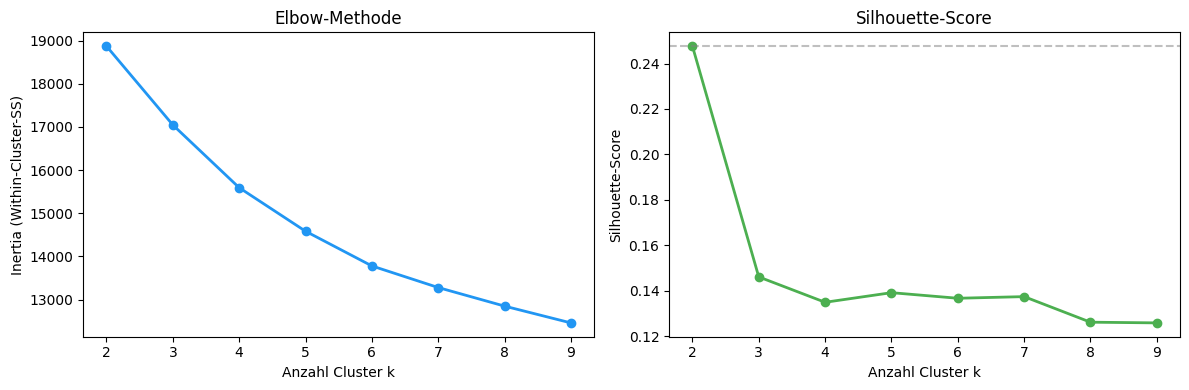

Optimale Clusteranzahl (max. Silhouette): k=2 (Score=0.248)


In [12]:
# ── Skill-Vektoren auf finales Sample einschränken ────────────────────────
skill_sub = skill_vectors.loc[skill_vectors.index.isin(final["soc_code"])].fillna(0)
final_with_skills = final.set_index("soc_code").join(skill_sub, how="inner")

X = skill_sub.values
print(f"Clusteranalyse-Input: {X.shape[0]} Berufe × {X.shape[1]} standardisierte Dimensionen")

# ── Elbow + Silhouette ─────────────────────────────────────────────────────
inertias   = []
silhouettes = []
K_range    = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, "o-", color="#2196F3", linewidth=2)
ax1.set_xlabel("Anzahl Cluster k")
ax1.set_ylabel("Inertia (Within-Cluster-SS)")
ax1.set_title("Elbow-Methode")

ax2.plot(K_range, silhouettes, "o-", color="#4CAF50", linewidth=2)
ax2.set_xlabel("Anzahl Cluster k")
ax2.set_ylabel("Silhouette-Score")
ax2.set_title("Silhouette-Score")
ax2.axhline(max(silhouettes), color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES / "6_1_cluster_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]
print(f"Optimale Clusteranzahl (max. Silhouette): k={best_k} (Score={max(silhouettes):.3f})")


In [13]:
# ── Finale K-Means Lösung ─────────────────────────────────────────────────
K_FINAL = best_k  # ggf. manuell überschreiben: K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X)

# Cluster-Zuordnung ins finale Sample eintragen
skill_sub_reset = skill_sub.reset_index()
cluster_df = pd.DataFrame({"soc_code": skill_sub.index, "cluster": cluster_labels})
final = final.merge(cluster_df, on="soc_code", how="left")

# Cluster-Profil: mittlerer E_j und Hauptgruppen-Verteilung
cluster_profile = final.groupby("cluster").agg(
    n_berufe=("soc_code", "count"),
    E_j_mean=("E_j", "mean"),
    E_sub_mean=("E_sub_j", "mean"),
    E_aug_mean=("E_aug_j", "mean"),
    delta_bfs_mean=("delta_bfs", "mean"),
    hg_mode=("main_group", lambda x: x.mode()[0])
).round(3)

print(f"=== Cluster-Profile (k={K_FINAL}) ===")
print(cluster_profile.to_string())


=== Cluster-Profile (k=2) ===
         n_berufe  E_j_mean  E_sub_mean  E_aug_mean  delta_bfs_mean  hg_mode
cluster                                                                     
0             370     0.286       0.257       0.326           8.066        2
1             201     0.127       0.118       0.140           3.078        3


## 6.1.5 PCA-Visualisierung

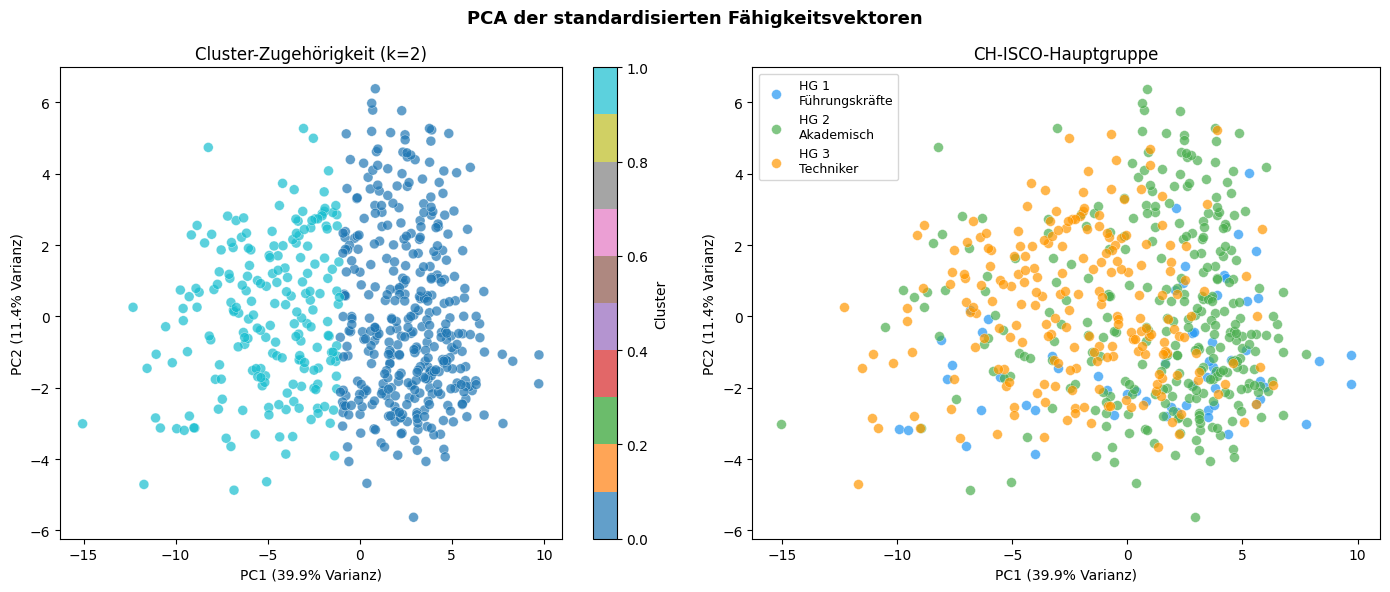

Erklärte Varianz PC1+PC2: 51.3%


In [14]:
# ── PCA auf 2 Komponenten für Visualisierung ──────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("PCA der standardisierten Fähigkeitsvektoren", fontsize=13, fontweight="bold")

# Links: nach Cluster
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                        c=cluster_labels, cmap="tab10", alpha=0.7, s=50, edgecolors="white", linewidth=0.3)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
ax1.set_title(f"Cluster-Zugehörigkeit (k={K_FINAL})")
plt.colorbar(scatter1, ax=ax1, label="Cluster")

# Rechts: nach Hauptgruppe
for hg in [1, 2, 3]:
    mask = final.set_index("soc_code").reindex(skill_sub.index)["main_group"] == hg
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=hg_labels[hg], color=colors[hg], alpha=0.7, s=50, edgecolors="white", linewidth=0.3)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
ax2.set_title("CH-ISCO-Hauptgruppe")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "6_1_pca_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Erklärte Varianz PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")


In [15]:
# ── EDA-Datensatz mit Cluster-Labels speichern ────────────────────────────
final.to_csv(FIGURES / "final_sample_clustered.csv", index=False)
print("Gespeichert → data/processed/analysis_prep/final_sample_clustered.csv ✓")
print()
print("=== EDA Zusammenfassung ===")
print(f"  Berufe im Sample:      {len(final)}")
print(f"  Berufe mit ΔBFS_j:     {final['delta_bfs'].notna().sum()}")
print(f"  Ausreisser (IQR):      {final['is_outlier'].sum() if 'is_outlier' in final.columns else 'N/A'}")
print(f"  Cluster (k={K_FINAL}):         {K_FINAL}")
print(f"  Mittlerer E_j:         {final['E_j'].mean():.3f}")


Gespeichert → data/processed/analysis_prep/final_sample_clustered.csv ✓

=== EDA Zusammenfassung ===
  Berufe im Sample:      571
  Berufe mit ΔBFS_j:     550
  Ausreisser (IQR):      23
  Cluster (k=2):         2
  Mittlerer E_j:         0.230
